# gCRL-VAE — Norman 2019 (100 % gamma 1.1) — boosted reconstruction

**Training**: control cells + single-TF perturbations  
**Test**: double-TF perturbations (already in `adata.obs['set'] == 'test'`)

Steps:
1. Load data, reassign training doubles → test
2. Compute eigengenes on the cleaned AnnData
3. Train gCRL-VAE
4. Predict double perturbations
5. Evaluate (centroid distance)

In [1]:
# ensuring all packages are reloaded each time I run a cell
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "../../src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from gcrl.grn.eigengenes import compute_eigengenes
from gcrl.training.train_gcrl_vae import VAEConfig, train_gcrl_vae
from gcrl.evaluation.prediction_eval import evaluate_predictions

In [3]:
# control panel
_ctrl_labels = ["unperturbed", "control", "ctrl"]

## 1. Load data

In [4]:
DATA_PATH = "../../data/real/Norman2019/Norman2019_processed_100pct_gamma1p1.h5ad"
OUT_DIR   = "../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon"

adata = ad.read_h5ad(DATA_PATH)
print(f"Loaded: {adata.shape[0]} cells × {adata.shape[1]} genes")

Loaded: 35048 cells × 2703 genes


## 2. Compute eigengenes

In [5]:
compute_eigengenes(
    adata,
    community_col="community",
    reference_query='intervention == "unperturbed"',
    mode="all_cells",
    method="PC",
    seed=42,
)
eig = adata.obsm["X_comm_eig"]
n_eig = eig.shape[1]  # p+1 = n_communities + 1
print(f"Eigengene matrix: {eig.shape}  (n_cells × n_communities+1)")

Eigengene matrix: (35048, 8)  (n_cells × n_communities+1)


## 3. Train gCRL-VAE

In [6]:
cfg = VAEConfig(
    outdir          = OUT_DIR,
    epochs          = 100,
    batch_size      = 32,
    lr              = 1e-3,
    lambda_sparse   = 0.1,   # L1 regulariser
    lambda_mcc      = 0.1,   # reduced: MCC reaches 0.8 easily, contribution ~0.08
    beta_kld_max    = 1.0,   # reduced: KLD is regulariser, not reconstruction
    alpha_mmd_max   = 10.0,  # boosted 10x: MMD raw ~0.27 -> contribution ~2.7
    use_tf_only     = True,
    use_GRN_priors  = True,
    seed            = 0,
)

model, history = train_gcrl_vae(adata, cfg, eigengenes_key="X_comm_eig")

gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon/


In [7]:
# Reload cell — skip when running the full notebook top-to-bottom
# (model and history are already in memory from the training cell above).
# Uncomment to reload a previously saved model without retraining.

# import torch
# model = torch.load("../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon/best_model.pt",
#                    map_location="cpu", weights_only=False)
# model.eval()

# import json
# with open("../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon/training_history.json") as f:
#     history = json.load(f)

# import pandas as pd
# df_hist = pd.DataFrame(history)
# df_hist.head()

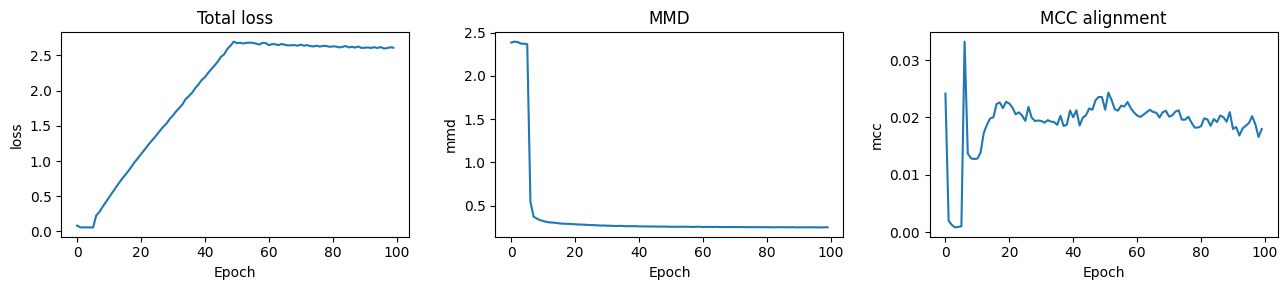

In [8]:
# Training curves
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, col, title in zip(
    axes,
    ["loss", "mmd", "mcc"],
    ["Total loss", "MMD", "MCC alignment"],
):
    ax.plot(df_hist["epoch"], df_hist[col])
    ax.set_xlabel("Epoch"); ax.set_ylabel(col); ax.set_title(title)
plt.tight_layout()
plt.show()

## 4. Predict double perturbations

In [9]:
preds = model.predict(
    adata,
    set_key          = "set",
    intervention_key = "intervention",
    cell_type_key    = "cell_type",
    control_labels   = tuple(_ctrl_labels),
    seed             = 42,
)
print(f"Predictions: {preds.shape[0]} cells across {preds.obs['intervention'].nunique()} conditions")
preds.obs.head()

Predictions: 3877 cells across 12 conditions


,set,cell_type,intervention,test_cell_idx,control_cell_idx
0,prediction,K562,AHR+FEV,AACTTTCGTACGAAAT-5-0-0,CGAGCCACAGACTCGC-5-0-1
1,prediction,K562,AHR+FEV,TTGAACGAGGCACATG-5-0-0,GATCGTATCCTCAATT-4-0-1
2,prediction,K562,AHR+FEV,CACAGGCAGCAGACTG-3-0-0,AGATTGCAGTAGATGT-2-0-1
3,prediction,K562,AHR+FEV,AACTCCCCACGACGAA-7-0-0,TACTTGTGTAGCGCTC-8-0-1
4,prediction,K562,AHR+FEV,CATCAAGCACCTATCC-1-0-0,ATTATCCGTCTGGTCG-4-0-1


## 5. Evaluate

In [10]:
metrics = evaluate_predictions(
    adata          = adata,
    preds          = preds,
    output_dir     = OUT_DIR,
    control_labels = tuple(_ctrl_labels),
)
metrics.sort_values(["metric_name", "method", "metric_value"])

,cell_type,intervention,method,metric_name,metric_value,n_test_cells,n_pred_cells
66,K562,TBX3+TBX2,actual,centroid_distance,4.831360,1167,1167
6,K562,AHR+KLF1,actual,centroid_distance,5.112339,481,481
36,K562,FOXA3+FOXF1,actual,centroid_distance,5.972594,175,175
24,K562,FOXA1+FOXL2,actual,centroid_distance,6.221781,192,192
54,K562,LYL1+CEBPB,actual,centroid_distance,6.352083,192,192
...,...,...,...,...,...,...,...
51,K562,FOXA3+HOXB9,worst_case,rmse,0.113111,329,329
45,K562,FOXA3+FOXL2,worst_case,rmse,0.118203,130,130
3,K562,AHR+FEV,worst_case,rmse,0.135213,276,276
21,K562,FOSB+CEBPE,worst_case,rmse,0.146678,151,151


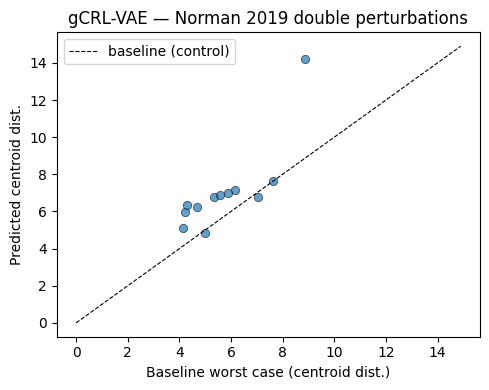

Median centroid distance      : 6.7711
Median baseline (worst case)  : 5.4667
Median baseline (perfect)     : 1.8756


In [11]:
# Pivot to wide format for plotting: one row per (cell_type, intervention, metric)
metrics_wide = metrics.pivot_table(
    index=["cell_type", "intervention", "n_test_cells", "n_pred_cells"],
    columns=["method", "metric_name"],
    values="metric_value",
).reset_index()
metrics_wide.columns = ["_".join(c).strip("_") for c in metrics_wide.columns]

# Scatter: predicted vs worst-case centroid distance
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(
    metrics_wide["worst_case_centroid_distance"],
    metrics_wide["actual_centroid_distance"],
    alpha=0.7, edgecolors="k", linewidths=0.5,
)
lim = max(metrics_wide["worst_case_centroid_distance"].max(),
          metrics_wide["actual_centroid_distance"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="baseline (control)")
ax.set_xlabel("Baseline worst case (centroid dist.)")
ax.set_ylabel("Predicted centroid dist.")
ax.set_title("gCRL-VAE — Norman 2019 double perturbations")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median centroid distance      : {metrics_wide['actual_centroid_distance'].median():.4f}")
print(f"Median baseline (worst case)  : {metrics_wide['worst_case_centroid_distance'].median():.4f}")
print(f"Median baseline (perfect)     : {metrics_wide['perfect_baseline_centroid_distance'].median():.4f}")

## 6. Baseline: discrepancy-VAE

Two variants, same hyperparameters, same seed as gCRL-VAE:

| Variant | `use_tf_only` | `z_dim` | Description |
|---|---|---|---|
| `cmvae_full` | False | 19 (= c_dim) | original CMVAE — one latent per intervened TF |
| `cmvae_comp` | False | n_eig (= p+1) | compressed CMVAE — same latent dim as gCRL-VAE |

`use_GRN_priors=False` for both → soft MLP routing, no MCC term.

In [12]:
_cmvae_base = dict(
    epochs         = 100,
    batch_size     = 32,
    lr             = 1e-3,
    lambda_sparse  = 0.1,    # L1 regulariser
    lambda_mcc     = 0.1,    # irrelevant when use_GRN_priors=False
    beta_kld_max   = 1.0,    # reduced
    alpha_mmd_max  = 10.0,   # boosted 10x
    use_tf_only    = False,
    use_GRN_priors = False,
    seed           = 0,
)

# --- 6a. original CMVAE: z_dim = c_dim (no z_dim override) ---
OUT_DIR_CMVAE_FULL = "../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon_cmvae_full"
cfg_cmvae_full = VAEConfig(outdir=OUT_DIR_CMVAE_FULL, z_dim=None, **_cmvae_base)
model_cmvae_full, _ = train_gcrl_vae(adata, cfg_cmvae_full, eigengenes_key="X_comm_eig")

# --- 6b. compressed CMVAE: z_dim = n_eig (same as gCRL-VAE) ---
OUT_DIR_CMVAE_COMP = "../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon_cmvae_comp"
cfg_cmvae_comp = VAEConfig(outdir=OUT_DIR_CMVAE_COMP, z_dim=n_eig, **_cmvae_base)
model_cmvae_comp, _ = train_gcrl_vae(adata, cfg_cmvae_comp, eigengenes_key="X_comm_eig")

gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon_cmvae_full/
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/vae_100pct_gamma1p1_boost_recon_cmvae_comp/


In [13]:
_predict_kwargs = dict(
    set_key          = "set",
    intervention_key = "intervention",
    cell_type_key    = "cell_type",
    control_labels   = tuple(_ctrl_labels),
    seed             = 42,
)

preds_cmvae_full = model_cmvae_full.predict(adata, **_predict_kwargs)
preds_cmvae_comp = model_cmvae_comp.predict(adata, **_predict_kwargs)

for label, p in [("cmvae_full", preds_cmvae_full), ("cmvae_comp", preds_cmvae_comp)]:
    print(f"{label}: {p.shape[0]} cells, {p.obs['intervention'].nunique()} conditions")

cmvae_full: 3877 cells, 12 conditions
cmvae_comp: 3877 cells, 12 conditions


## 7. Compare gCRL-VAE vs both discrepancy-VAE variants (prediction quality)

In [14]:
metrics_cmvae_full = evaluate_predictions(
    adata=adata, preds=preds_cmvae_full,
    output_dir=OUT_DIR_CMVAE_FULL, control_labels=tuple(_ctrl_labels),
)
metrics_cmvae_comp = evaluate_predictions(
    adata=adata, preds=preds_cmvae_comp,
    output_dir=OUT_DIR_CMVAE_COMP, control_labels=tuple(_ctrl_labels),
)

_model_runs = [
    (f"gCRL-VAE (z={n_eig}, GRN priors)",       metrics),
    ("discrepancy-VAE (z=19, original)", metrics_cmvae_full),
    (f"discrepancy-VAE (z={n_eig}, compressed)", metrics_cmvae_comp),
]
metrics_all = pd.concat(
    [m.assign(model=label) for label, m in _model_runs],
    ignore_index=True,
)

summary = (
    metrics_all
    .groupby(["model", "method", "metric_name"])["metric_value"]
    .median()
    .reset_index()
    .pivot_table(index=["metric_name", "method"], columns="model", values="metric_value")
)
print("Median metrics across all double-perturbation conditions:")
summary

Median metrics across all double-perturbation conditions:


model                               discrepancy-VAE (z=19, original)  \
metric_name       method                                               
centroid_distance actual                                    7.631663   
                  perfect_baseline                          1.875614   
                  worst_case                                5.466724   
rmse              actual                                    0.146790   
                  perfect_baseline                          0.036076   
                  worst_case                                0.105149   

model                               discrepancy-VAE (z=8, compressed)  \
metric_name       method                                                
centroid_distance actual                                     7.762368   
                  perfect_baseline                           1.875614   
                  worst_case                                 5.466724   
rmse              actual                                     0.149304   
                  perfect_baseline                           0.036076   
                  worst_case                                 0.105149   

model                               gCRL-VAE (z=8, GRN priors)  
metric_name       method                                        
centroid_distance actual                              6.771098  
                  perfect_baseline                    1.875614  
                  worst_case                          5.466724  
rmse              actual                              0.130237  
                  perfect_baseline                    0.036076  
                  worst_case                          0.105149

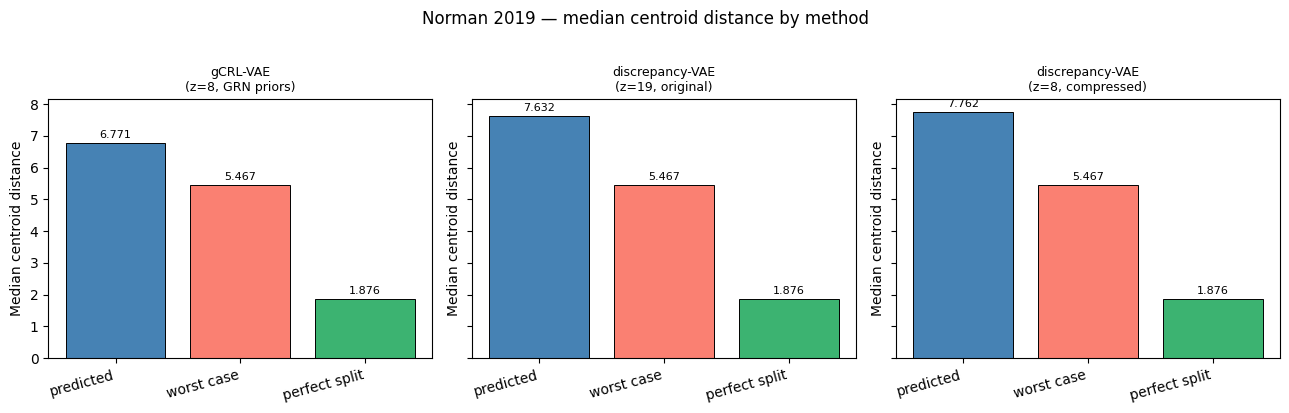

In [15]:
_plot_runs = [
    (f"gCRL-VAE\n(z={n_eig}, GRN priors)",        metrics.assign(model="gCRL-VAE")),
    ("discrepancy-VAE\n(z=19, original)",  metrics_cmvae_full.assign(model="cmvae_full")),
    (f"discrepancy-VAE\n(z={n_eig}, compressed)", metrics_cmvae_comp.assign(model="cmvae_comp")),
]
methods_order = ["actual", "worst_case", "perfect_baseline"]
colors = {"actual": "steelblue", "worst_case": "salmon", "perfect_baseline": "mediumseagreen"}

# --- bar chart: median centroid distance ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (title, m) in zip(axes, _plot_runs):
    cd = m[m["metric_name"] == "centroid_distance"]
    medians = cd.groupby("method")["metric_value"].median().reindex(methods_order)
    bars = ax.bar(
        medians.index, medians.values,
        color=[colors[k] for k in medians.index],
        edgecolor="k", linewidth=0.7,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("Median centroid distance")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["predicted", "worst case", "perfect split"], rotation=15, ha="right")

plt.suptitle("Norman 2019 — median centroid distance by method", y=1.02)
plt.tight_layout()
plt.show()

## 8. MCC alignment: mu vs eigengenes across all cells

Compare how well the latent means `mu` align with the precomputed eigengenes `E`
(stored in `adata.obsm["X_comm_eig"]`) for the two models that share the same
latent dimension (z=n_eig): **gCRL-VAE** and **compressed discrepancy-VAE**.

For each model we:
1. Encode all cells (unperturbed + single + double) to get `mu` (shape: n_cells × n_eig).
2. Use `optimize_partial_mcc(E, mu)` to find the best linear map X such that `E ≈ mu @ X`,
   then report the achieved partial-MCC score (higher = better alignment).
3. Plot the Pearson correlation matrix between `E` columns and `mu @ X` columns,
   broken down by cell group (unperturbed, single perturbation, double perturbation).

In [16]:
import scipy.sparse as sp
from gcrl.alignment.partial_mcc import optimize_partial_mcc, correlation_matrix

def _encode_all(m, adata):
    """Encode all cells in adata; returns mu (n_cells, z_dim)."""
    m.eval()
    if m.cfg.use_tf_only and "kind" in adata.var.columns:
        tf_mask = (adata.var["kind"].astype(str) == "TF").values  # numpy bool, not pandas Series
        X_in = adata.X[:, tf_mask]
    else:
        X_in = adata.X
    X_np = X_in.toarray() if sp.issparse(X_in) else np.asarray(X_in, dtype=np.float32)
    enc = m.encode_batch(X_np.astype(np.float32))
    return enc["mu"]   # (n_cells, z_dim)

# Encode all cells for the two z=n_eig models
mu_gcrl = _encode_all(model,            adata)   # gCRL-VAE
mu_comp = _encode_all(model_cmvae_comp, adata)   # compressed CMVAE

# Eigengene matrix (all cells, n_eig = p+1 columns)
E_all = adata.obsm["X_comm_eig"][:, :n_eig].astype(np.float32)

# Cell-group masks
_is_double_all = adata.obs["intervention"].str.contains(r"[+;,]", regex=True).values
_is_ctrl_all   = adata.obs["intervention"].isin(_ctrl_labels).values
_is_single_all = ~_is_ctrl_all & ~_is_double_all

groups = {
    "unperturbed":         _is_ctrl_all,
    "single perturbation": _is_single_all,
    "double perturbation": _is_double_all,
    "all cells":           np.ones(adata.n_obs, dtype=bool),
}

print(f"{'Group':<25} {'n_cells':>8}  {'MCC (gCRL-VAE)':>16}  {'MCC (CMVAE-comp)':>18}")
print("-" * 72)

_mcc_results = {}
for group_name, mask in groups.items():
    E_g  = E_all[mask]
    mu_g = mu_gcrl[mask]
    mu_c = mu_comp[mask]

    score_gcrl, _, _ = optimize_partial_mcc(E_g, mu_g, steps=500, seed=42)
    score_comp, _, _ = optimize_partial_mcc(E_g, mu_c, steps=500, seed=42)

    _mcc_results[group_name] = {"gcrl": score_gcrl, "comp": score_comp}
    print(f"{group_name:<25} {mask.sum():>8d}  {score_gcrl:>16.4f}  {score_comp:>18.4f}")

Group                      n_cells    MCC (gCRL-VAE)    MCC (CMVAE-comp)
------------------------------------------------------------------------


unperturbed                   8907            0.9864              0.1493


single perturbation          18811            0.9797              0.2307


double perturbation           7330            0.9808              0.2647


all cells                    35048            0.9807              0.2332


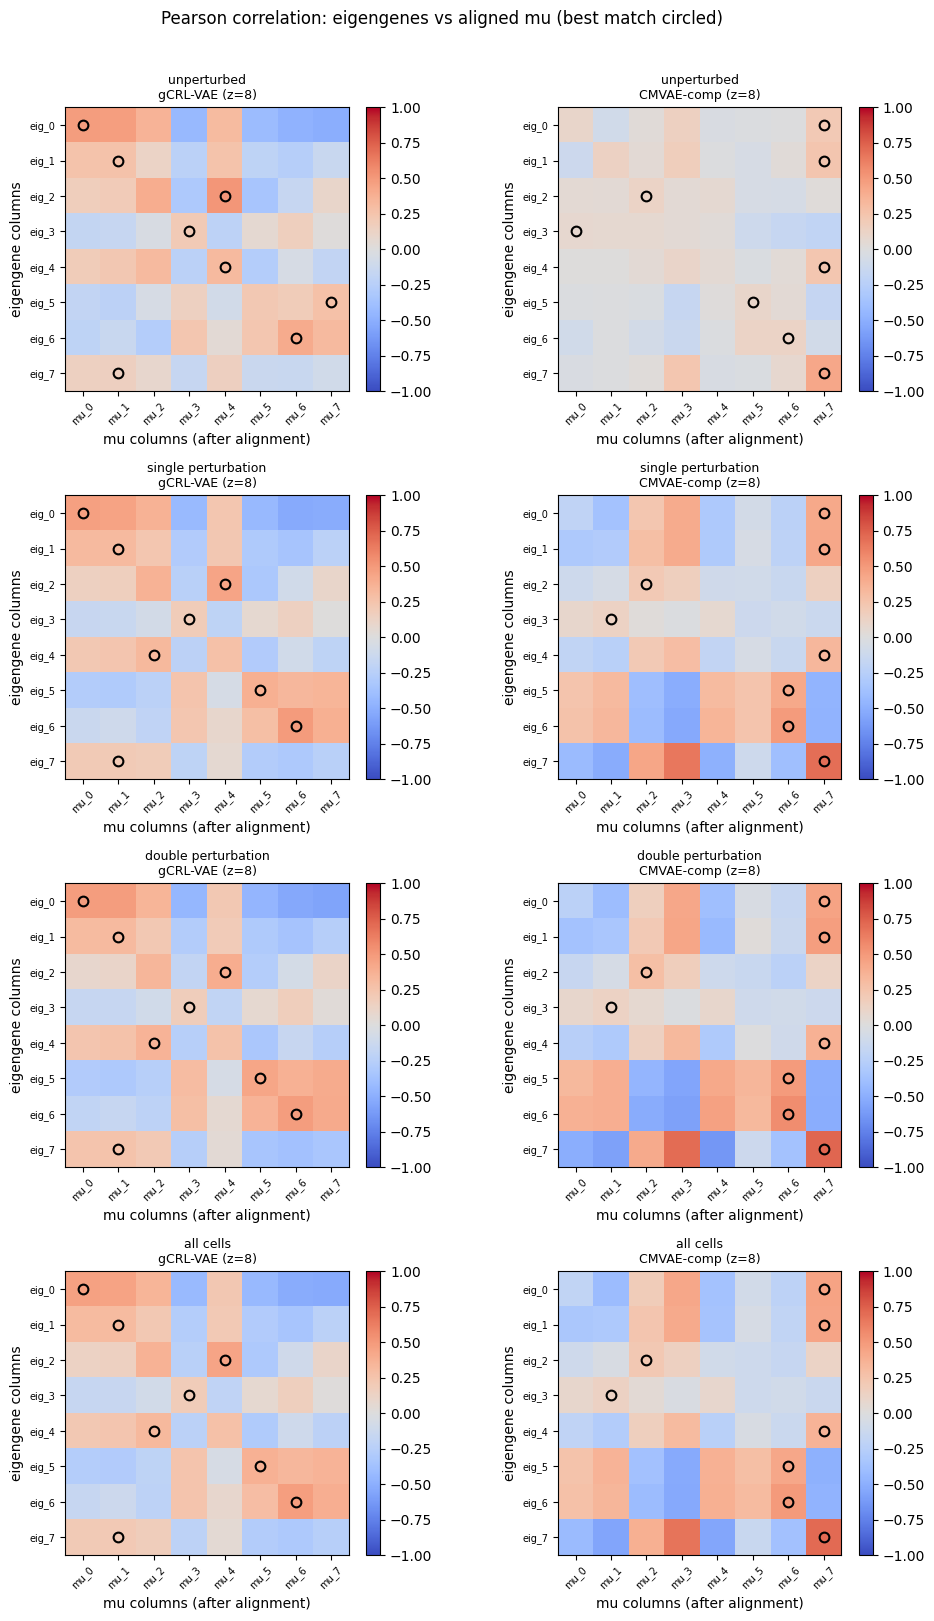

In [17]:
# Correlation matrices for each group, both models side-by-side
n_groups = len(groups)
fig, axes = plt.subplots(n_groups, 2, figsize=(10, 4 * n_groups))

model_pairs = [
    (f"gCRL-VAE (z={n_eig})", mu_gcrl),
    (f"CMVAE-comp (z={n_eig})", mu_comp),
]

for row, (group_name, mask) in enumerate(groups.items()):
    E_g = E_all[mask]
    for col, (model_label, mu_all) in enumerate(model_pairs):
        ax = axes[row, col]
        mu_g = mu_all[mask]

        # Optimise alignment then compute correlation matrix
        _, X_opt, BX_opt = optimize_partial_mcc(E_g, mu_g, steps=500, seed=42)
        C = correlation_matrix(E_g, BX_opt)
        p = C.shape[0]

        im = ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1, origin="upper")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Circle the best-match column for each eigengene row
        for i in range(p):
            best_j = int(np.argmax(C[i, :]))
            ax.plot(best_j, i, "ko", ms=7, mfc="none", mew=1.5)

        ax.set_xticks(range(p)); ax.set_xticklabels([f"mu_{k}" for k in range(p)], fontsize=7, rotation=45)
        ax.set_yticks(range(p)); ax.set_yticklabels([f"eig_{k}" for k in range(p)], fontsize=7)
        ax.set_xlabel("mu columns (after alignment)")
        ax.set_ylabel("eigengene columns")
        ax.set_title(f"{group_name}\n{model_label}", fontsize=9)

plt.suptitle("Pearson correlation: eigengenes vs aligned mu (best match circled)", y=1.01)
plt.tight_layout()
plt.show()